# Funciones de Transferencia ITAE Óptimas

Función para generar funciones de transferencia con criterio ITAE (Integral of Time-weighted Absolute Error) para sistemas de control con cero error de posición o cero error de velocidad.

In [1]:
import control as ctrl
import numpy as np
import matplotlib.pyplot as plt


!rm -f ubicarpolos.py && wget -O ubicarpolos.py https://raw.githubusercontent.com/nebisman/control-material/refs/heads/main/notebooks/ubicarpolos.py
from ubicarpolos import asigne_polos, calcular_itae

--2026-04-24 13:15:14--  https://raw.githubusercontent.com/nebisman/control-material/refs/heads/main/notebooks/ubicarpolos.py
Resolviendo raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.110.133, 185.199.111.133, 185.199.108.133, ...
Conectando con raw.githubusercontent.com (raw.githubusercontent.com)[185.199.110.133]:443... conectado.
Petición HTTP enviada, esperando respuesta... 200 OK
Longitud: 3249 (3,2K) [text/plain]
Guardando como: ‘ubicarpolos.py’

ubicarpolos.py      100%[===================>]   3,17K  --.-KB/s    en 0s      

2026-04-24 13:15:14 (10,2 MB/s) - ‘ubicarpolos.py’ guardado [3249/3249]



ImportError: cannot import name 'calcular_itae' from 'ubicarpolos' (/home/leonardo/datos/share_desktop/universidad nacional/Materias/Materias 2026/2026-I/Control/control-material/notebooks/ubicarpolos.py)

## Celda 1: Ejemplo de uso con respuesta al escalón

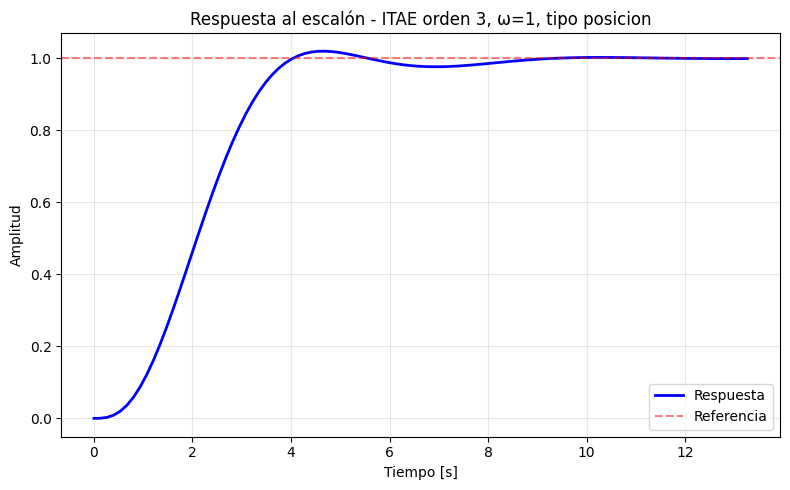

In [4]:
# Ejemplo: función ITAE de orden 3, omega=1, tipo 'p'
T = calcular_itae(orden=3, omega=1, tipo="p")


# Respuesta al escalón
t, y = ctrl.step_response(T)

plt.figure(figsize=(8, 5))
plt.plot(t, y, 'b-', linewidth=2)
plt.axhline(y=1, color='r', linestyle='--', alpha=0.5, label='Referencia')
plt.xlabel('Tiempo [s]')
plt.ylabel('Amplitud')
plt.title('Respuesta al escalón - ITAE orden 3, ω=1, tipo posicion')
plt.legend(['Respuesta', 'Referencia'])
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Respuesta al escalón para ITAE orden 3, tipo "p", con ω = 1, 2, 5, 10

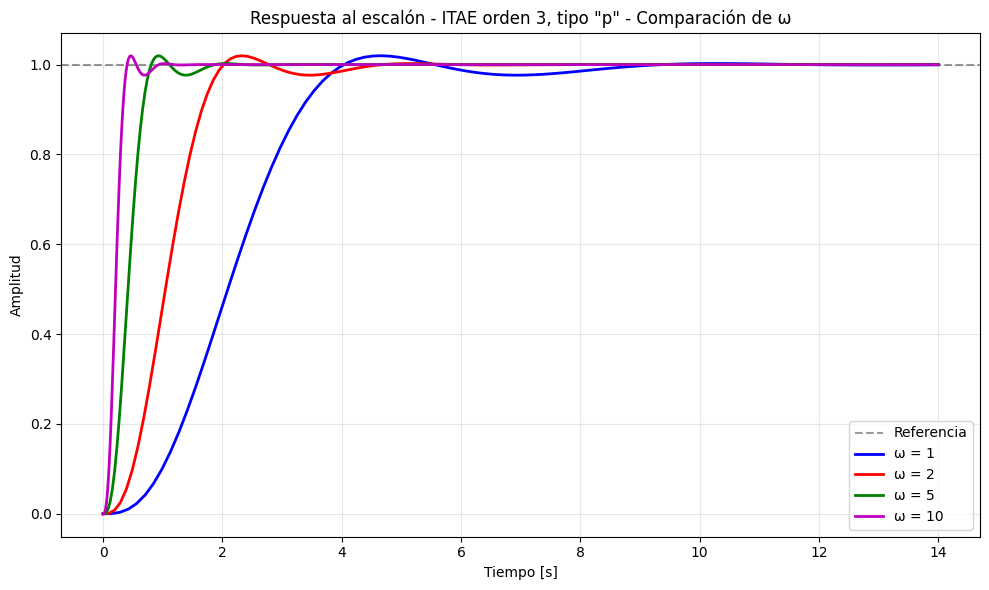

In [8]:
omegas = [1, 2, 5, 10]
colores = ['b', 'r', 'g', 'm']

plt.figure(figsize=(10, 6))
plt.axhline(y=1, color='k', linestyle='--', alpha=0.4, label='Referencia')

for omega, color in zip(omegas, colores):
    T = calcular_itae(orden=3, omega=omega, tipo="p")
    t, y = ctrl.step_response(T, 14)
    plt.plot(t, y, color=color, linewidth=2, label=f'ω = {omega}')

plt.xlabel('Tiempo [s]')
plt.ylabel('Amplitud')
plt.title('Respuesta al escalón - ITAE orden 3, tipo "p" - Comparación de ω')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()